# Car Prediction Using Machine Learning

In [66]:
# Import of required libraries

# Data processing and linear algebra
import numpy as np 
import pandas as pd 

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder

# Loading the Dataset

In [2]:
try:
    train_df = pd.read_csv('datasets/train.csv')
    print("Train csv loaded successfully!")
except FileNotFoundError:
    print("Error: The file 'train.csv' was not found. Please check the file path.")

Train csv loaded successfully!


In [3]:
train_df.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


# Exploratory Data Analysis

In [4]:
train_df.shape

(188533, 13)

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     183450 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      186081 non-null  object
 11  clean_title   167114 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 18.7+ MB


In [6]:
train_df.describe(include ="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,188533.0,NaN,NaN,NaN,94266.0,54424.933488,0.0,47133.0,94266.0,141399.0,188532.0
brand,188533,57,Ford,23088,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,188533,1897,F-150 XLT,2945,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_year,188533.0,NaN,NaN,NaN,2015.829998,5.660967,1974.0,2013.0,2017.0,2020.0,2024.0
milage,188533.0,NaN,NaN,NaN,65705.295174,49798.158076,100.0,24115.0,57785.0,95400.0,405000.0
fuel_type,183450,7,Gasoline,165940,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine,188533,1117,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,3462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,188533,52,A/T,49904,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ext_col,188533,319,Black,48658,NaN,NaN,NaN,NaN,NaN,NaN,NaN
int_col,188533,156,Black,107674,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
train_df.isna().sum()

id                  0
brand               0
model               0
model_year          0
milage              0
fuel_type        5083
engine              0
transmission        0
ext_col             0
int_col             0
accident         2452
clean_title     21419
price               0
dtype: int64

In [8]:
# Checking percentages of missing values
(train_df[['fuel_type', 'accident', 'clean_title']].isna().mean() *100)

fuel_type       2.696080
accident        1.300568
clean_title    11.360876
dtype: float64

In [9]:
print(train_df.columns)

Index(['id', 'brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')


In [10]:
train_df['fuel_type']=train_df.groupby(['brand', 'model'])['fuel_type'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown'))

In [11]:
train_df['accident'] = train_df['accident'].fillna('unknown')

In [12]:
train_df["clean_title"] = train_df['clean_title'].fillna('unknown')

In [13]:
train_df.isna().sum()

id              0
brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

In [14]:
train_df.duplicated().sum()

np.int64(0)

In [15]:
features = train_df.drop('price', axis = 1)

In [16]:
target = train_df['price']

In [17]:
df_model = features

In [18]:
categorical_cols = train_df.select_dtypes(include='object').columns
numerical_cols = train_df.select_dtypes(exclude='object').columns

In [19]:
categorical_cols 

Index(['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col',
       'int_col', 'accident', 'clean_title'],
      dtype='object')

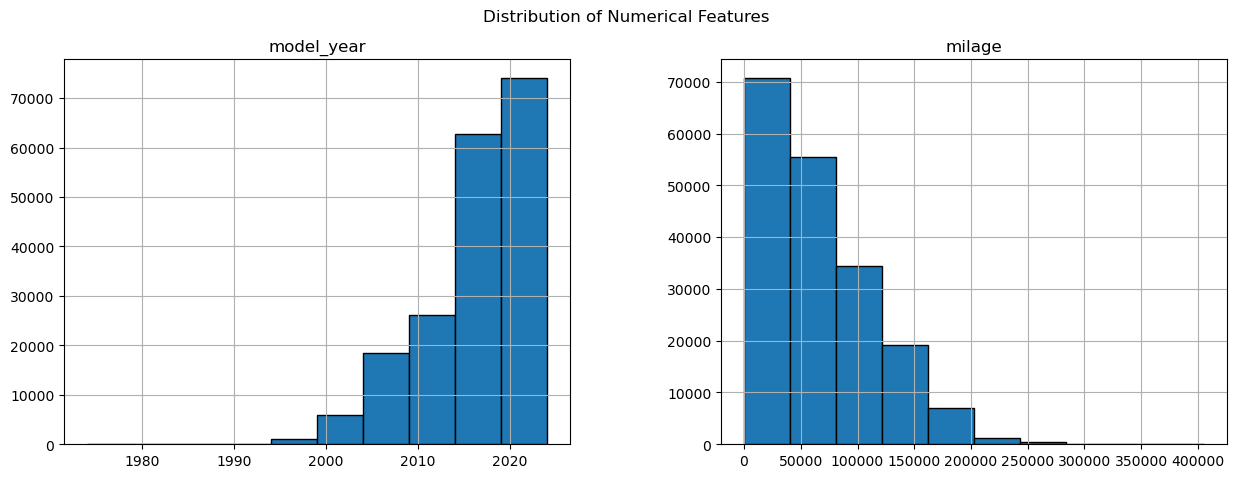

In [20]:
train_df[['model_year', 'milage']].hist(bins=10, edgecolor='black', figsize=(15,5))
plt.suptitle('Distribution of Numerical Features')
plt.show()

In [21]:
corr = train_df[['model_year', 'milage']].corr()

<Axes: >

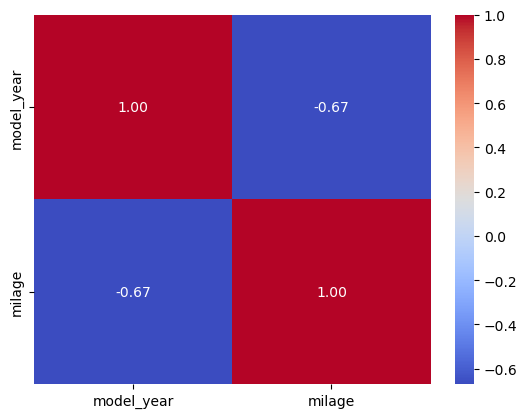

In [22]:
sns.heatmap(corr, annot = True, cmap='coolwarm', fmt='.2f')

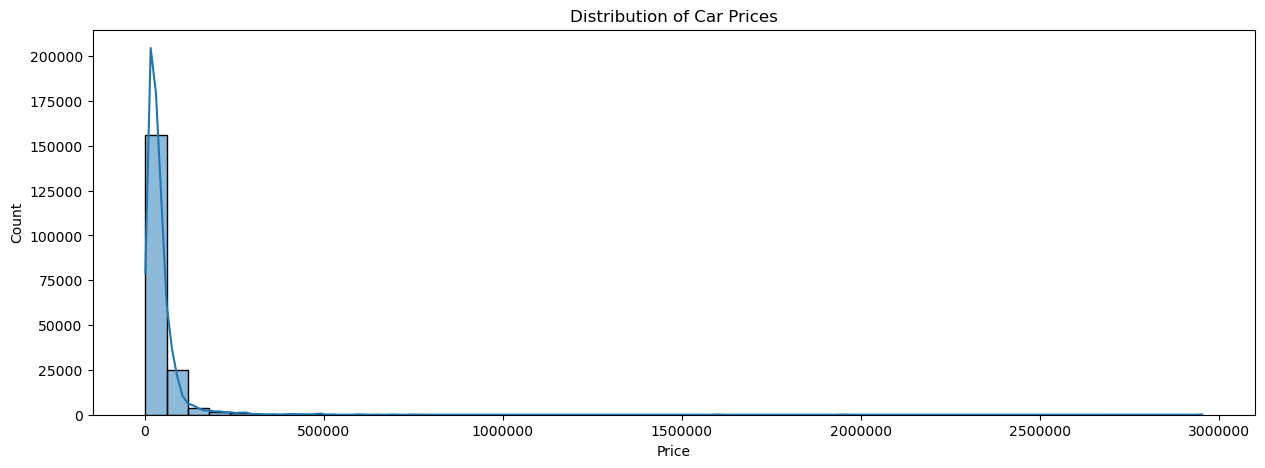

In [23]:
plt.figure(figsize=(15,5))
sns.histplot(train_df['price'], kde=True, bins=50)
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

C:\Users\Ademola\AppData\Local\Temp\ipykernel_6596\1638252392.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=train_df, x='brand',y='price', palette='Set1', alpha=0.7)


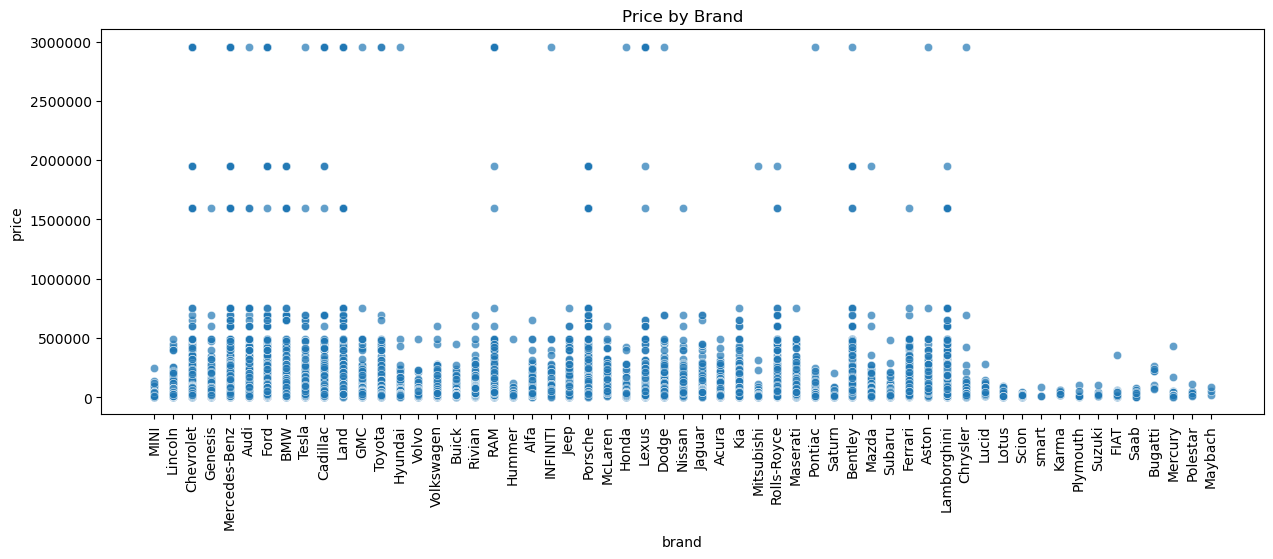

In [24]:
plt.figure(figsize=(15,5))
sns.scatterplot(data=train_df, x='brand',y='price', palette='Set1', alpha=0.7)
plt.title('Price by Brand')
plt.xticks(rotation=90)
plt.ticklabel_format(style='plain', axis='y')

plt.show()

C:\Users\Ademola\AppData\Local\Temp\ipykernel_6596\2026296562.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=train_df, x='model_year',y='price', palette='Set1', alpha=0.7)


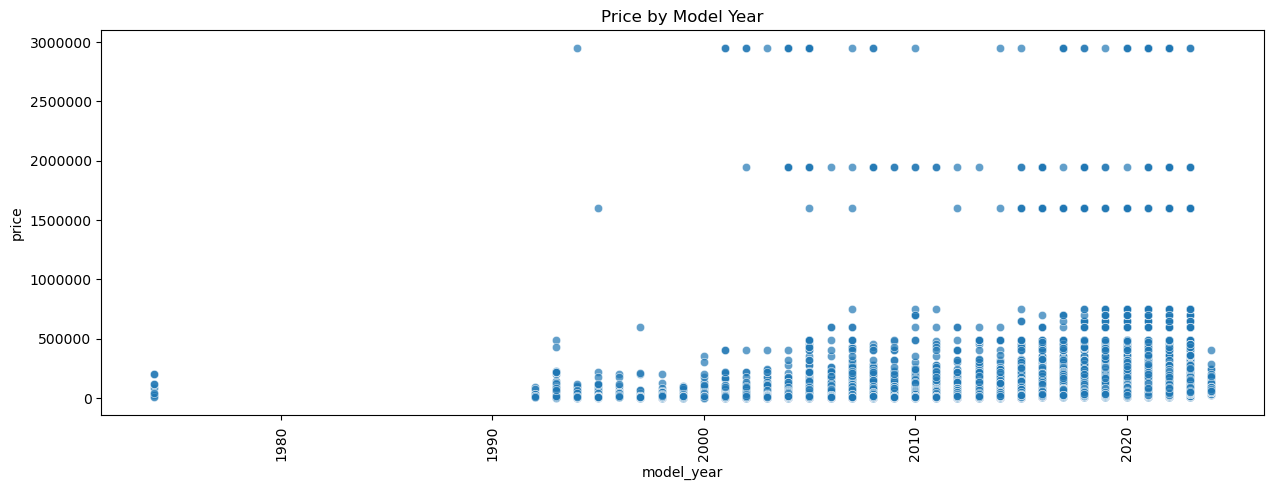

In [25]:
plt.figure(figsize=(15,5))
sns.scatterplot(data=train_df, x='model_year',y='price', palette='Set1', alpha=0.7)
plt.title('Price by Model Year')
plt.xticks(rotation=90)
plt.ticklabel_format(style='plain', axis='y')

plt.show()

C:\Users\Ademola\AppData\Local\Temp\ipykernel_6596\1696678211.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=train_df, x='milage',y='price', palette='Set1', alpha=0.7)


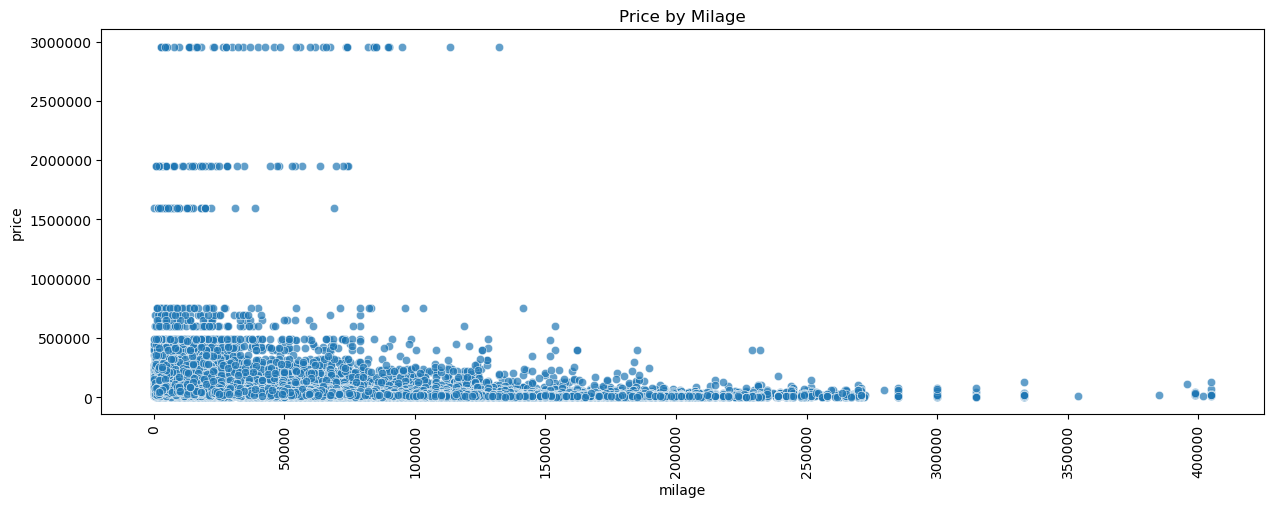

In [26]:
plt.figure(figsize=(15,5))
sns.scatterplot(data=train_df, x='milage',y='price', palette='Set1', alpha=0.7)
plt.title('Price by Milage')
plt.xticks(rotation=90)
plt.ticklabel_format(style='plain', axis='y')

plt.show()

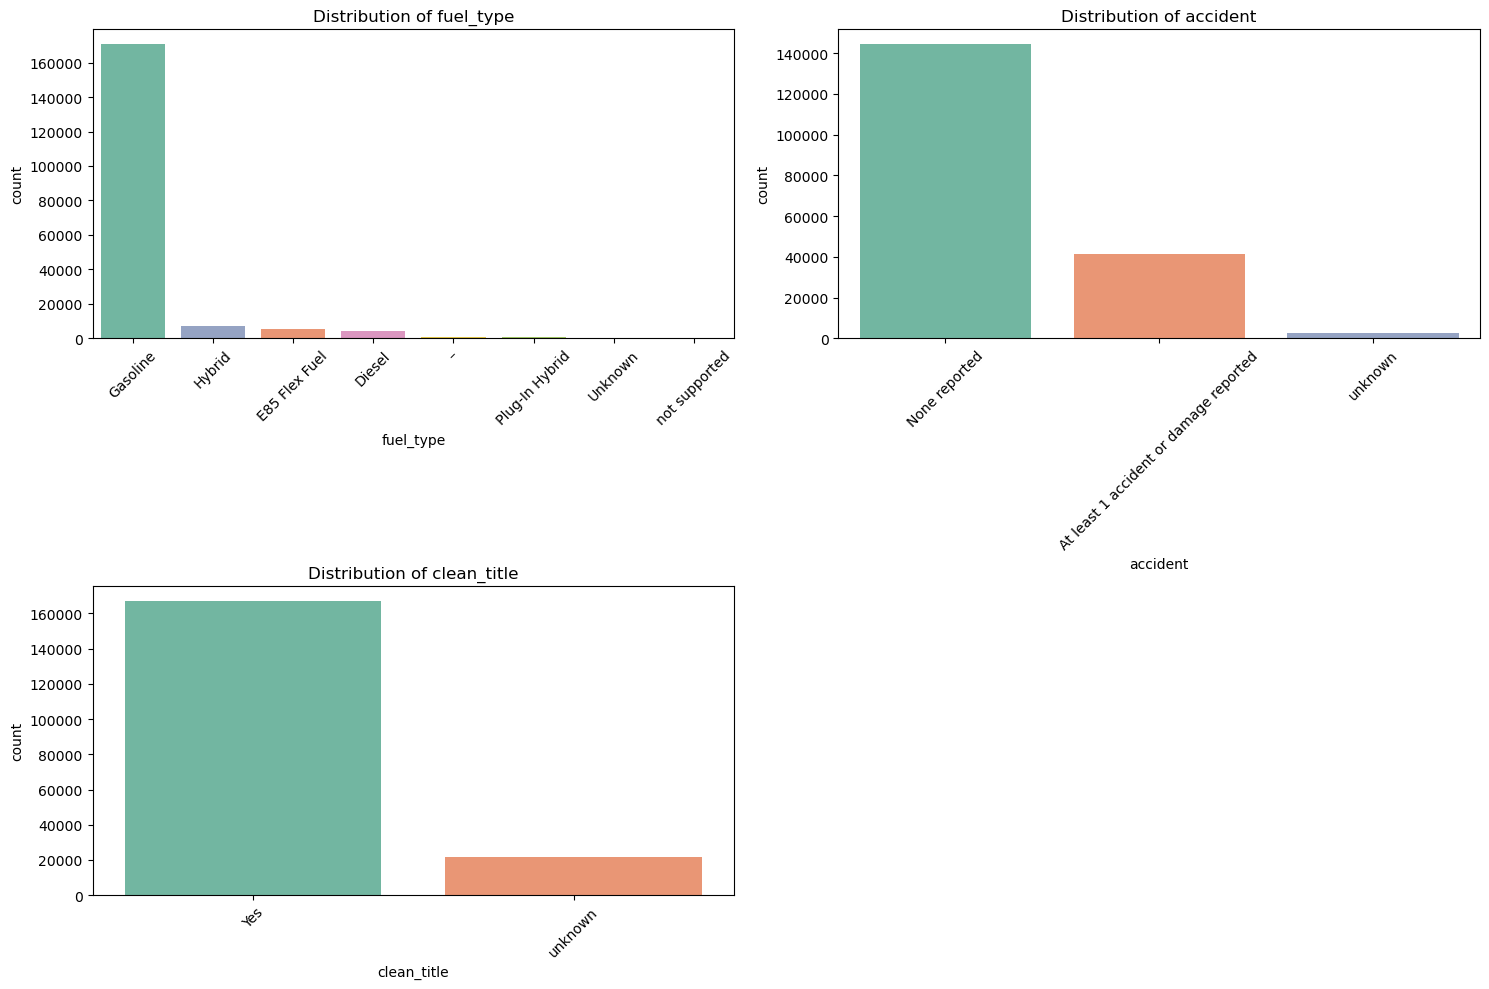

In [27]:
plt.figure(figsize=(15,10))
for i, col in enumerate(['fuel_type', 'accident', 'clean_title']):
    plt.subplot(2,2, i+1)
    sns.countplot(data=train_df, x=col, hue=col, palette='Set2', order=train_df[col].value_counts().index, legend = False)
    plt.xticks(rotation=45)

    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [28]:
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

In [29]:
X = df_model

In [30]:
y = target

# Train-Test Split

In [31]:
# Splitting the data into training (80%) and testing (20%) sets 
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
X

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
0,0,31,495,2007,213000,2,116,38,312,71,1,0
1,1,28,930,2002,143250,2,366,38,263,10,0,0
2,2,9,1575,2002,136731,1,640,38,38,71,1,0
3,3,16,758,2017,19500,2,863,49,29,14,1,0
4,4,36,1077,2021,7388,2,259,23,29,10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
188528,188528,8,604,2017,49000,2,866,49,304,10,1,0
188529,188529,36,206,2018,28600,2,770,31,304,14,0,0
188530,188530,36,223,2021,13650,2,921,23,304,14,1,0
188531,188531,3,1471,2022,13895,2,512,1,82,14,1,1


In [33]:
y

0          4200
1          4999
2         13900
3         45000
4         97500
          ...  
188528    27500
188529    30000
188530    86900
188531    84900
188532    28995
Name: price, Length: 188533, dtype: int64

# Training the model

In [34]:
xgb_model = XGBRegressor(objective ="reg:squarederror", n_jobs = -1, random_state=42)

In [35]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7, 9],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.05, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0]
}

In [36]:
random_search = RandomizedSearchCV(
        estimator=xgb_model,
        param_distributions=param_grid,
        n_iter = 20,
        scoring='neg_mean_squared_error',
        cv=3,
        verbose=2,
        random_state=42
    )

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=3, min_child_weight=3, n_estimators=100, subsample=1.0; total time=   1.3s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=3, min_child_weight=3, n_estimators=100, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=3, min_child_weight=3, n_estimators=100, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=7, min_child_weight=3, n_estimators=300, subsample=0.05; total time=   2.2s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=7, min_child_weight=3, n_estimators=300, subsample=0.05; total time=   2.3s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=7, min_child_weight=3, n_estimators=300, subsample=0.05; total time=   2.3s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=9, min_child_weight=5, n_estimators=100, subsample=0.7; tot

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.85, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,20
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [37]:
random_search.best_params_

{'subsample': 1.0,
 'n_estimators': 200,
 'min_child_weight': 3,
 'max_depth': 3,
 'learning_rate': 0.1,
 'colsample_bytree': 0.85}

In [38]:
xgb_best_model= random_search.best_estimator_

In [39]:
y_pred = xgb_best_model.predict(X_val)

In [40]:
y_pred

array([53802.582, 36330.48 , 35239.902, ..., 21579.307,  9552.115,
       50490.863], shape=(37707,), dtype=float32)

In [ ]:
RMSE = np.sqrt(mean_squared_error(y_val, y_pred))

In [42]:
RMSE

np.float64(68067.24956981881)

In [43]:
test=pd.read_csv('datasets/test.csv')
test.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
0,188533,Land,Rover LR2 Base,2015,98000,Gasoline,240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,White,Beige,None reported,Yes
1,188534,Land,Rover Defender SE,2020,9142,Hybrid,395.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,8-Speed A/T,Silver,Black,None reported,Yes
2,188535,Ford,Expedition Limited,2022,28121,Gasoline,3.5L V6 24V PDI DOHC Twin Turbo,10-Speed Automatic,White,Ebony,None reported,NaN
3,188536,Audi,A6 2.0T Sport,2016,61258,Gasoline,2.0 Liter TFSI,Automatic,Silician Yellow,Black,None reported,NaN
4,188537,Audi,A6 2.0T Premium Plus,2018,59000,Gasoline,252.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Gray,Black,None reported,Yes


In [44]:
test.shape

(125690, 12)

In [45]:
test.isna().sum()

id                  0
brand               0
model               0
model_year          0
milage              0
fuel_type        3383
engine              0
transmission        0
ext_col             0
int_col             0
accident         1632
clean_title     14239
dtype: int64

In [46]:
test.duplicated().sum()

np.int64(0)

In [47]:
test['fuel_type']=test.groupby(['brand', 'model'])['fuel_type'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown'))
test['accident'] = test['accident'].fillna('unknown')
test["clean_title"] = test['clean_title'].fillna('unknown')

In [48]:
test_categorical_cols = test.select_dtypes(include='object').columns

In [49]:
test_categorical_cols

Index(['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col',
       'int_col', 'accident', 'clean_title'],
      dtype='object')

In [50]:
for col in test_categorical_cols:
    le = LabelEncoder()
    test[col] = le.fit_transform(test[col])
    label_encoders[col] =le

In [51]:
test.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
0,188533,26,1388,2015,98000,2,326,16,302,10,1,0
1,188534,26,1375,2020,9142,3,787,31,261,14,1,0
2,188535,14,636,2022,28121,2,541,3,302,57,1,1
3,188536,3,182,2016,61258,2,193,39,259,14,1,1
4,188537,3,181,2018,59000,2,365,38,127,14,1,0


In [52]:
y_test_pred = xgb_best_model.predict(test)
y_test_pred[0:5]

array([ 16302.765, 149981.9  ,  57211.86 ,  86649.164,  30168.287],
      dtype=float32)

In [65]:
submission=pd.DataFrame({"id":test['id'],"Price":y_test_pred})
submission.to_csv("datasets/Submission.csv",index=False)